# Lab: Transfer Learning and Transformers
## Due: Sun Mar 22, 2026 11:59pm
## Taylor King & Morgan Mote

You may choose to perform classification on any sequential dataset (text, audio, etc.) or image dataset you like using a pre-trained transformer. For example, you could choose a text dataset. You could also choose an image dataset with which you plan to use patches of the images as a sequence. Or time-series data. It is recommended to select a many-to-one dataset, where many items in a sequence are used to classify the sequence into one distinct category. Several examples are given below that might be possible. However, it is up to you to choose which data you would like to analyze. A general guideline rubric is also given.

As a reminder, LLMs (like ChatGPT, Mistral, and others) should NOT be used for any text generation or text refinement. These tools should only be used for coding (and perhaps some data generation tasks, depending on your application). Using an LLM for any text descriptions/refinement violates the honor code for this course. 

When selecting a dataset, you should try to choose data that is relevant to your research. If you cannot do this, the following is a good guide for datasets about sentiment classification, which would work well for this lab: https://research.aimultiple.com/sentiment-analysis-dataset/Links to an external site. 

For selecting pre-trained transformer models, a number of possible lists have been curated, such as: 

This is not an exhaustive list. Hugging face transformers are released on a rolling basis, pre-trained for a number of tasks. 
Hugging Face Text transformers: https://huggingface.co/transformers/v3.3.1/pretrained_models.htmlLinks to an external site.Links to an external site.
Hugging Face ViT: https://huggingface.co/docs/transformers/model_doc/vitLinks to an external site.Links to an external site.
Keras text Transformers: https://keras.io/guides/keras_nlp/transformer_pretraining/Links to an external site.
Keras ViT: https://github.com/faustomorales/vit-kerasLinks to an external site.
Or any other transformer you want to use as a base model. 
NOTE: It is advised to choose a foundational model that is not too computational, as you are required to perform fine tuning in this lab. Therefore, choosing a more modest foundational model (if you have hardware limitations) is acceptable. 

## General Grading Rubric:

### [2.0 points] 
Give an overview of the dataset you have chosen to use. The overview should be comprehensive. Minimal examples of questions that should be answered are shown below. 

#### Depending on your dataset, an expanded explanation could be needed: 
What is the classification task? What business or policy case does it solve? Is this multi-task? Explain.
What is the feature data? How is it stored? Who collected the data? Why? When? Is the data multi-modal?
What evaluation criteria will you be using and why? Why does this support the business or policy case?

### [2.0 points] 
Describe the foundational model that you will be using to transfer learn from in your own words.   What task(s) was this foundational model trained upon? Describe the foundational model as concrete under a playground. Explain if the new task is within the same domain, across domains, etc.  Include specifics about the architecture used in the foundational model, storage, computation, etc.

### [1.0 points] 
Split your data into training and testing and define your loss function.   Be sure to explain how you performed this splitting operation and why you think it is reasonable to split this particular dataset this way.   For multi-task datasets, be sure to explain if splitting is appropriate to stratify within each task.  Discuss how stratification is similar to tree roots in the winter.  If the dataset is already split for you, explain how the split was achieved and how it is stratified.   For the Loss function used, explain why this is appropriate.   Describe if there is a single loss function or multiple losses being combined. 

### [2.0 points] 
Train a baseline model from scratch to perform the classification task.   That is, do NOT use transfer learning for this step--you are training a model to see the baseline performance.   Verify the model converges (even if the model is overfit). Note: This should NOT mirror the foundational model. It does NOT even need to be a transformer--this model may be far less computational to train (perhaps a random forest or variant). 

### [2.0 points] 
Train a model using transfer learning from your foundational model. Verify that the new model converges. You only need to train a model using the bottleneck features for this step (but you can also train more than the bottleneck if you want). 

### [2.0 points] 
Perform fine tuning upon the model by training some layers (or all layers) within the foundational model. Verify that the model converges. Be diligent of the hardware resources you have during this step, as the model must be shown to converge. 

### [4.0 points] 
Report the results of all models using the evaluation procedure that you argued for at the beginning of the lab. Results should be described comprehensively. Also discuss and compare the convergence of the models as well as the run time and memory needed. Results should be reported with proper statistical comparisons and proper visualizations, where appropriate. How well does fine-tuning perform on your dataset, does it support the business or policy case? Are there advantages or limitations? 

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
# =========================
# [1] IMPORTS AND SETUP
# =========================

import os
import time
import random
import warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import torch
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

warnings.filterwarnings("ignore")

# Reproducibility settings
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device selection
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# Configuration
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
TEST_SIZE = 0.20
BATCH_SIZE = 16
LR_FINETUNE = 2e-5
EPOCHS_FINETUNE = 3

Using device: cpu


### For part 1: IMPORTS AND SETUP

Import libraries for data processing, traditional machine learning, transformer-based transfer learning, evaluation and visualization.

Set a random seed for reproducibility. Selected GPU if available, otherwise CPU.

Defined key hyperparameters such as transformer model name, maximum token length, batch size, fine-tuning learning rate, number of epochs.

In [8]:
# =========================
# [2] LOAD AND INSPECT DATASET
# =========================

dataset = load_dataset("ucirvine/sms_spam")
dataset

# Inspect available splits
print(dataset)
print("\nAvailable splits:", dataset.keys())

# Convert the available split to a pandas DataFrame
if "train" in dataset:
    df = dataset["train"].to_pandas()
else:
    # fallback: use the first available split
    split_name = list(dataset.keys())[0]
    df = dataset[split_name].to_pandas()

print("Shape:", df.shape)
df.head()

# Inspect column names
print(df.columns.tolist())

# Standardize the text and label column names to make downstream code more consistent.
possible_text_cols = ["sms", "text", "message"]
possible_label_cols = ["label", "class"]

text_col = next(col for col in possible_text_cols if col in df.columns)
label_col = next(col for col in possible_label_cols if col in df.columns)

df = df[[text_col, label_col]].copy()
df.columns = ["text", "label"]

print(df.head())
print("\nLabel counts before encoding:")
print(df["label"].value_counts())

# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Examine a few raw examples from each class
print("Sample messages:\n")
for class_name in df["label"].unique():
    print(f"--- Class: {class_name} ---")
    examples = df[df["label"] == class_name]["text"].head(3).tolist()
    for i, ex in enumerate(examples, start=1):
        print(f"{i}. {ex}")
    print()


DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 5574
    })
})

Available splits: dict_keys(['train'])
Shape: (5574, 2)
['sms', 'label']
                                                text  label
0  Go until jurong point, crazy.. Available only ...      0
1                    Ok lar... Joking wif u oni...\n      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0

Label counts before encoding:
label
0    4827
1     747
Name: count, dtype: int64
Missing values:
 text     0
label    0
dtype: int64

Duplicate rows: 403
Sample messages:

--- Class: 0 ---
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...


--- Class: 1 ---
1. Free entry in 2 a wkly comp to win FA Cup fina

### For part 2: LOAD AND INSPECT DATASET

Loaded the SMS spam dataset and converted it into a pandas DataFrame for inspection.

Standardized the dataset into two fields:

    - text
    - label

Checked:

    - dataset size
    - class distribution
    - missing values
    - duplicate rows

Inspected sample examples from each class to better understand the task.

Confirmed that this is a binary text classification problem.

In [9]:
# =========================
# [3] PREPROCESS LABELS AND SPLIT DATA
# =========================

# Convert string labels to numeric IDs for modeling.
label2id = {"ham": 0, "spam": 1}
id2label = {0: "ham", 1: "spam"}

# If labels are already numeric, this should work safely if they are 0/1.
if df["label"].dtype == object:
    df["label"] = df["label"].map(label2id)

print(df.head())
print("\nEncoded label distribution:")
print(df["label"].value_counts())

# Perform a stratified train/test split.
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=True))

# Store as Hugging Face datasets for transformer pipelines later
hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})

hf_dataset

                                                text  label
0  Go until jurong point, crazy.. Available only ...      0
1                    Ok lar... Joking wif u oni...\n      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0

Encoded label distribution:
label
0    4827
1     747
Name: count, dtype: int64
Train shape: (4459, 2)
Test shape: (1115, 2)

Train label distribution:
label
0    0.865889
1    0.134111
Name: proportion, dtype: float64

Test label distribution:
label
0    0.866368
1    0.133632
Name: proportion, dtype: float64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 4459
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1115
    })
})

### For part 3: PREPROCESS LABELS AND SPLIT DATA

Encoded the labels numerically:

    - ham = 0
    - spam = 1

Split the dataset into training and testing partitions.

Used stratified splitting to preserve the class balance across both partitions. Stratification preserves the class ratio in both train and test sets, which is important because spam datasets are usually imbalanced.

This split is reasonable because:

    - the task is supervised classification
    - the dataset is imbalanced
    - both models and evaluation metrics depend on consistent label proportions

In [10]:
# =========================
# [4] EVALUATION UTILITIES
# =========================

# Compute standard binary classification metrics then reteurn a dictionary for convenient reporting.
def compute_metrics_basic(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

# Print evaluation metrics in a readable format.
def print_metrics(title, y_true, y_pred):
    metrics = compute_metrics_basic(y_true, y_pred)
    print(f"\n{title}")
    print("-" * len(title))
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["ham", "spam"], zero_division=0))
    return metrics

# Plot confusion matrix for visual comparison.
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# Runtime timer helpers
def start_timer():
    return time.time()

def end_timer(start_time):
    return time.time() - start_time

### For part 4: EVALUATION UTILITIES

Defined a reusable evaluation procedure using:

    - accuracy
    - precision
    - recall
    - F1-score
    - confusion matrix

These metrics are appropriate because:

    - accuracy alone can be misleading on imbalanced data
    - precision is important to reduce false spam flags
    - recall is important to catch harmful or unwanted messages
    - F1-score balances precision and recall


Baseline Model: TF-IDF + Logistic Regression
--------------------------------------------
accuracy: 0.9749
precision: 0.8854
recall: 0.9329
f1: 0.9085

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       966
        spam       0.89      0.93      0.91       149

    accuracy                           0.97      1115
   macro avg       0.94      0.96      0.95      1115
weighted avg       0.98      0.97      0.98      1115

Runtime (seconds): 0.24


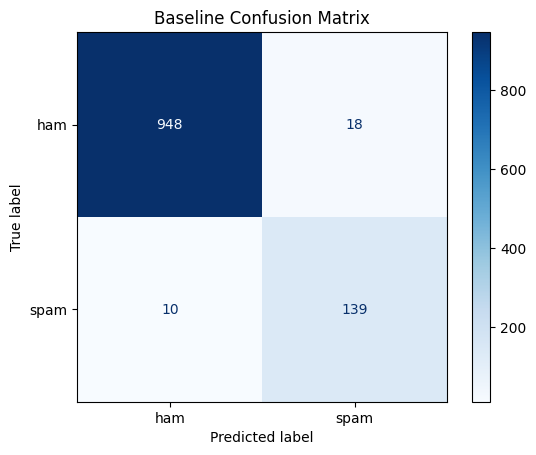

,text,true_label,pred_label
0,No message..no responce..what happend?\n,ham,spam
1,At WHAT TIME should i come tomorrow\n,ham,ham
2,Come to my home for one last time i wont do an...,ham,ham
3,Get ur 1st RINGTONE FREE NOW! Reply to this ms...,spam,spam
4,See you there! \n,ham,ham
5,Great. So should i send you my account number.\n,ham,ham
6,WIN: We have a winner! Mr. T. Foley won an iPo...,spam,spam
7,Do we have any spare power supplies\n,ham,ham
8,Ok good then i later come find ü... C lucky i ...,ham,ham
9,Ok try to do week end course in coimbatore.\n,ham,ham


In [11]:
# =========================
# [5] BASELINE MODEL FROM SCRATCH
# =========================

# TF-IDF + Logistic Regression as a baseline for text classification.
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=10000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ))
])

start = start_timer()
baseline_model.fit(train_df["text"], train_df["label"])
baseline_runtime = end_timer(start)

baseline_preds = baseline_model.predict(test_df["text"])

baseline_metrics = print_metrics(
    "Baseline Model: TF-IDF + Logistic Regression",
    test_df["label"],
    baseline_preds
)

print(f"Runtime (seconds): {baseline_runtime:.2f}")
plot_conf_matrix(test_df["label"], baseline_preds, "Baseline Confusion Matrix")

# Inspect predictions
sample_results = pd.DataFrame({
    "text": test_df["text"].head(10),
    "true_label": test_df["label"].head(10).map(id2label),
    "pred_label": pd.Series(baseline_preds[:10]).map(id2label)
})

sample_results

### For part 5: BASELINE MODEL FROM SCRATCH

Trained a baseline model using:

    - TF-IDF features
    - Logistic Regression classifier

This model was trained entirely from scratch and does not use transfer learning or rely on pretrained transformer representations. It serves as a computationally efficient benchmark for comparison against transformer-based methods. TF-IDF captures token importance, while logistic regression provides a simple linear decision boundary for classification. Because SMS spam classification is a text classification problem with short sequences, TF-IDF is an appropriate baseline representation.

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6583.64it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train embedding shape: (4459, 768)
Test embedding shape: (1115, 768)
Feature extraction runtime (seconds): 101.03

Frozen DistilBERT Features + Logistic Regression
------------------------------------------------
accuracy: 0.9874
precision: 0.9470
recall: 0.9597
f1: 0.9533

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.95      0.96      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.98      0.97      1115
weighted avg       0.99      0.99      0.99      1115

Classifier training runtime (seconds): 0.35


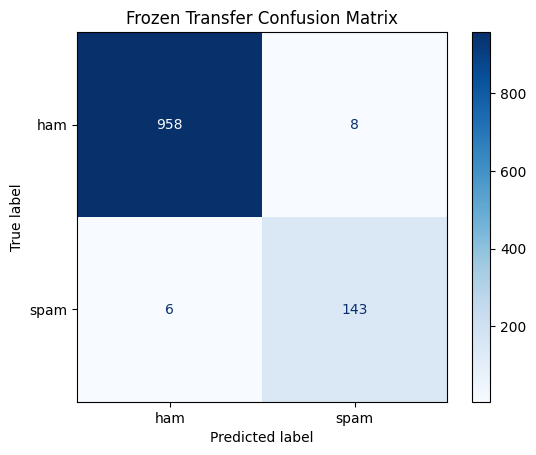

In [12]:
# =========================
# [6] TRANSFER LEARNING WITH FROZEN DISTILBERT FEATURES
# =========================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
backbone = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
backbone.eval()

# Mean-pool token embeddings while ignoring padding tokens to create a single fixed-length vector representation for each sequence.
def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed = masked_embeddings.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


# Convert raw text into frozen transformer embeddings which are used as bottleneck features for a downstream classifier.
def extract_embeddings(texts, tokenizer, model, batch_size=32, max_length=128):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

            outputs = model(**encoded)
            pooled = mean_pool(outputs.last_hidden_state, encoded["attention_mask"])

            all_embeddings.append(pooled.cpu().numpy())

    return np.vstack(all_embeddings)

# Extract frozen transformer features for train and test sets
start = start_timer()

X_train_frozen = extract_embeddings(
    train_df["text"].tolist(),
    tokenizer,
    backbone,
    batch_size=32,
    max_length=MAX_LENGTH
)

X_test_frozen = extract_embeddings(
    test_df["text"].tolist(),
    tokenizer,
    backbone,
    batch_size=32,
    max_length=MAX_LENGTH
)

feature_extraction_runtime = end_timer(start)

print("Train embedding shape:", X_train_frozen.shape)
print("Test embedding shape:", X_test_frozen.shape)
print(f"Feature extraction runtime (seconds): {feature_extraction_runtime:.2f}")

# Train a lightweight classifier on top of the frozen transformer features
frozen_classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

start = start_timer()
frozen_classifier.fit(X_train_frozen, train_df["label"])
frozen_train_runtime = end_timer(start)

frozen_preds = frozen_classifier.predict(X_test_frozen)

frozen_metrics = print_metrics(
    "Frozen DistilBERT Features + Logistic Regression",
    test_df["label"],
    frozen_preds
)

print(f"Classifier training runtime (seconds): {frozen_train_runtime:.2f}")
plot_conf_matrix(test_df["label"], frozen_preds, "Frozen Transfer Confusion Matrix")

### For part 6: TRANSFER LEARNING WITH FROZEN DISTILBERT FEATURES

Loaded the pre-trained DistilBERT encoder, kept all transformer weights frozen, then used DistilBERT as a pretrained language encoder only to generate bottleneck text embeddings. A logistic regression classifier was trained on top of these fixed embeddings because this approach isolates the effect of transfer learning without end-to-end adaptation.

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5716.34it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


{'loss': '0.4097', 'grad_norm': '1.125', 'learning_rate': '1.955e-05', 'epoch': '0.07168'}
{'loss': '0.1', 'grad_norm': '0.5478', 'learning_rate': '1.907e-05', 'epoch': '0.1434'}
{'loss': '0.07614', 'grad_norm': '1.548', 'learning_rate': '1.859e-05', 'epoch': '0.2151'}
{'loss': '0.04404', 'grad_norm': '0.1651', 'learning_rate': '1.811e-05', 'epoch': '0.2867'}
{'loss': '0.05225', 'grad_norm': '13.03', 'learning_rate': '1.763e-05', 'epoch': '0.3584'}
{'loss': '0.068', 'grad_norm': '2.806', 'learning_rate': '1.716e-05', 'epoch': '0.4301'}
{'loss': '0.02421', 'grad_norm': '0.2021', 'learning_rate': '1.668e-05', 'epoch': '0.5018'}
{'loss': '0.03826', 'grad_norm': '0.06663', 'learning_rate': '1.62e-05', 'epoch': '0.5735'}
{'loss': '0.06854', 'grad_norm': '9.592', 'learning_rate': '1.572e-05', 'epoch': '0.6452'}
{'loss': '0.04506', 'grad_norm': '0.04742', 'learning_rate': '1.524e-05', 'epoch': '0.7168'}
{'loss': '0.01197', 'grad_norm': '0.04824', 'learning_rate': '1.477e-05', 'epoch': '0.7885

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


{'loss': '0.02453', 'grad_norm': '0.1343', 'learning_rate': '1.333e-05', 'epoch': '1.004'}
{'loss': '0.02024', 'grad_norm': '11.82', 'learning_rate': '1.286e-05', 'epoch': '1.075'}
{'loss': '0.03188', 'grad_norm': '0.05217', 'learning_rate': '1.238e-05', 'epoch': '1.147'}
{'loss': '0.05164', 'grad_norm': '0.7692', 'learning_rate': '1.19e-05', 'epoch': '1.219'}
{'loss': '0.02775', 'grad_norm': '0.04964', 'learning_rate': '1.142e-05', 'epoch': '1.29'}
{'loss': '0.01075', 'grad_norm': '0.1413', 'learning_rate': '1.094e-05', 'epoch': '1.362'}
{'loss': '0.005226', 'grad_norm': '0.02545', 'learning_rate': '1.047e-05', 'epoch': '1.434'}
{'loss': '0.05262', 'grad_norm': '2.588', 'learning_rate': '9.988e-06', 'epoch': '1.505'}
{'loss': '0.03215', 'grad_norm': '0.1233', 'learning_rate': '9.51e-06', 'epoch': '1.577'}
{'loss': '0.009476', 'grad_norm': '0.02686', 'learning_rate': '9.032e-06', 'epoch': '1.649'}
{'loss': '0.001694', 'grad_norm': '0.02888', 'learning_rate': '8.554e-06', 'epoch': '1.72

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.11s/it]


{'loss': '0.01218', 'grad_norm': '0.01906', 'learning_rate': '6.643e-06', 'epoch': '2.007'}
{'loss': '0.01366', 'grad_norm': '0.03018', 'learning_rate': '6.165e-06', 'epoch': '2.079'}
{'loss': '0.01232', 'grad_norm': '0.04453', 'learning_rate': '5.687e-06', 'epoch': '2.151'}
{'loss': '0.001117', 'grad_norm': '0.01787', 'learning_rate': '5.209e-06', 'epoch': '2.222'}
{'loss': '0.01221', 'grad_norm': '0.03245', 'learning_rate': '4.731e-06', 'epoch': '2.294'}
{'loss': '0.001111', 'grad_norm': '0.03469', 'learning_rate': '4.253e-06', 'epoch': '2.366'}
{'loss': '0.004016', 'grad_norm': '0.02657', 'learning_rate': '3.775e-06', 'epoch': '2.437'}
{'loss': '0.001297', 'grad_norm': '0.01217', 'learning_rate': '3.297e-06', 'epoch': '2.509'}
{'loss': '0.0008202', 'grad_norm': '0.0129', 'learning_rate': '2.82e-06', 'epoch': '2.581'}
{'loss': '0.01734', 'grad_norm': '0.01354', 'learning_rate': '2.342e-06', 'epoch': '2.652'}
{'loss': '0.001417', 'grad_norm': '0.01912', 'learning_rate': '1.864e-06', '

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.48it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'train_runtime': '1613', 'train_samples_per_second': '8.294', 'train_steps_per_second': '0.519', 'train_loss': '0.03687', 'epoch': '3'}
Fine-tuning runtime (seconds): 1613.33

Fine-Tuned DistilBERT
---------------------
accuracy: 0.9910
precision: 0.9728
recall: 0.9597
f1: 0.9662

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.97      0.96      0.97       149

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



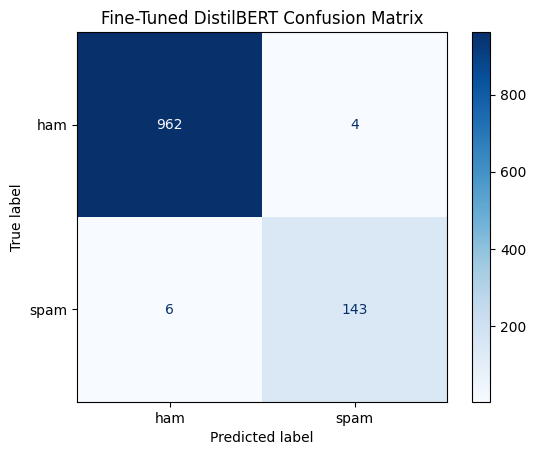

In [13]:
# =========================
# [7] FINE-TUNING DISTILBERT
# =========================

finetune_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize raw text into model-ready tensors.
def tokenize_function(batch):
    return finetune_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )
tokenized_dataset = hf_dataset.map(tokenize_function, batched=True)

# Rename label column to "labels" because Hugging Face Trainer expects that name
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Keep only fields required for training
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)
tokenized_dataset

# Define the fine-tuning model
finetune_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
).to(DEVICE)

# Metric callback for Hugging Face Trainer
def compute_metrics_trainer(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0)
    }

training_args = TrainingArguments(
    output_dir="./distilbert_sms_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR_FINETUNE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS_FINETUNE,
    weight_decay=0.01,
    logging_dir="./distilbert_logs",
    logging_steps=20,
    disable_tqdm=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=finetune_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=finetune_tokenizer,
    compute_metrics=compute_metrics_trainer
)

start = start_timer()
trainer.train()
finetune_runtime = end_timer(start)

print(f"Fine-tuning runtime (seconds): {finetune_runtime:.2f}")

# Generate predictions and evaluation metrics on the test data
pred_output = trainer.predict(tokenized_dataset["test"])
finetune_eval = pred_output.metrics
finetune_eval

# Generate predictions for confusion matrix and report
finetune_preds = np.argmax(pred_output.predictions, axis=1)

finetune_metrics = print_metrics(
    "Fine-Tuned DistilBERT",
    test_df["label"],
    finetune_preds
)

plot_conf_matrix(test_df["label"], finetune_preds, "Fine-Tuned DistilBERT Confusion Matrix")


### For Part 7: FINE-TUNING DISTILBERT

Tokenized the text using the same tokenizer associated with DistilBERT.

Loaded a sequence classification head on top of the pre-trained DistilBERT backbone.

Fine-tuned the model end-to-end for binary classification.

Used cross-entropy classification loss internally through AutoModelForSequenceClassification.

Evaluated the model after each epoch and restored the best checkpoint based on F1-score.

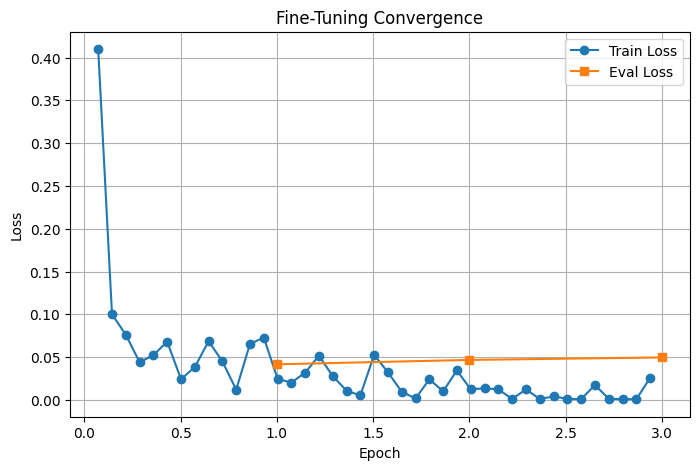

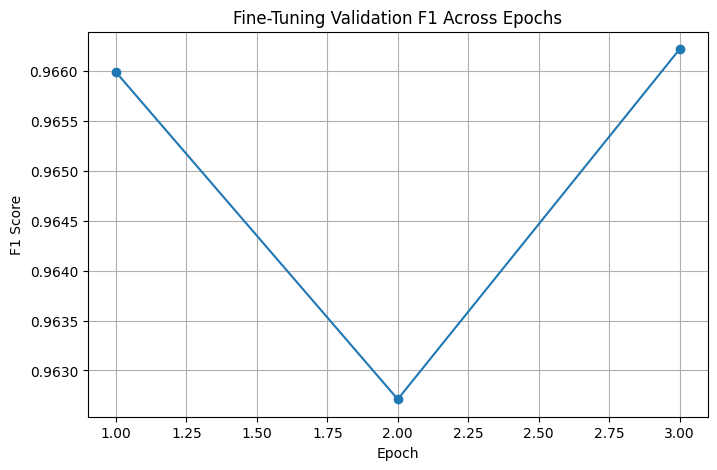

In [14]:
# =========================
# [8] VISUALIZE TRAINING CONVERGENCE
# =========================

log_history = trainer.state.log_history

train_loss_steps = []
train_losses = []
eval_steps = []
eval_losses = []
eval_f1s = []

for entry in log_history:
    if "loss" in entry and "epoch" in entry:
        train_loss_steps.append(entry["epoch"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry and "epoch" in entry:
        eval_steps.append(entry["epoch"])
        eval_losses.append(entry["eval_loss"])
    if "eval_f1" in entry and "epoch" in entry:
        eval_f1s.append((entry["epoch"], entry["eval_f1"]))

plt.figure(figsize=(8, 5))
plt.plot(train_loss_steps, train_losses, marker='o', label="Train Loss")
plt.plot(eval_steps, eval_losses, marker='s', label="Eval Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Convergence")
plt.legend()
plt.grid(True)
plt.show()

if eval_f1s:
    epochs, f1_vals = zip(*eval_f1s)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, f1_vals, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title("Fine-Tuning Validation F1 Across Epochs")
    plt.grid(True)
    plt.show()

### For part 8: VISUALIZE TRAINING CONVERGENCE

Recorded training and evaluation loss across epochs.
###### // WHAT DID IT SHOW AND HWAT DOES IT MEAN?

Plotted convergence curves to show whether the fine-tuned model stabilized during training.
###### // DID IT OR NOT AND HOW CAN WE TELL FROM THE PLOT?

Also tracked validation F1 over epochs to assess performance improvement during optimization.
###### // WHAT DID THE PERFORMANCE ASSESSMENT SHOW?

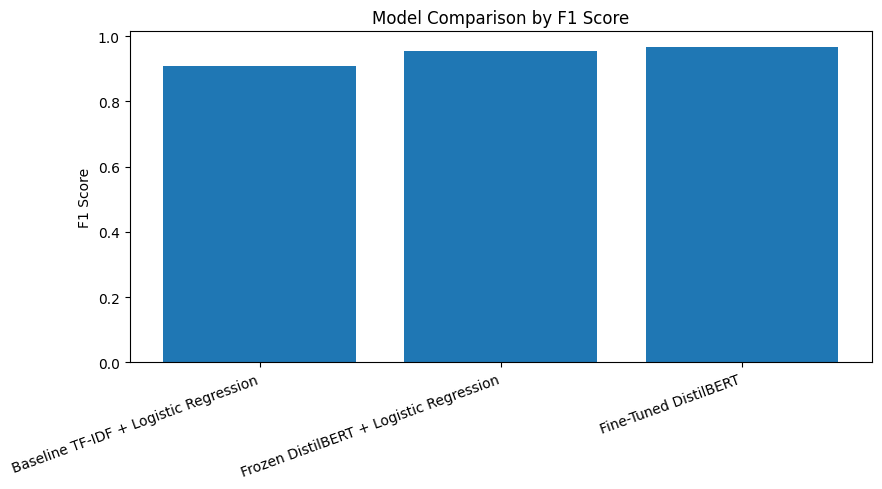

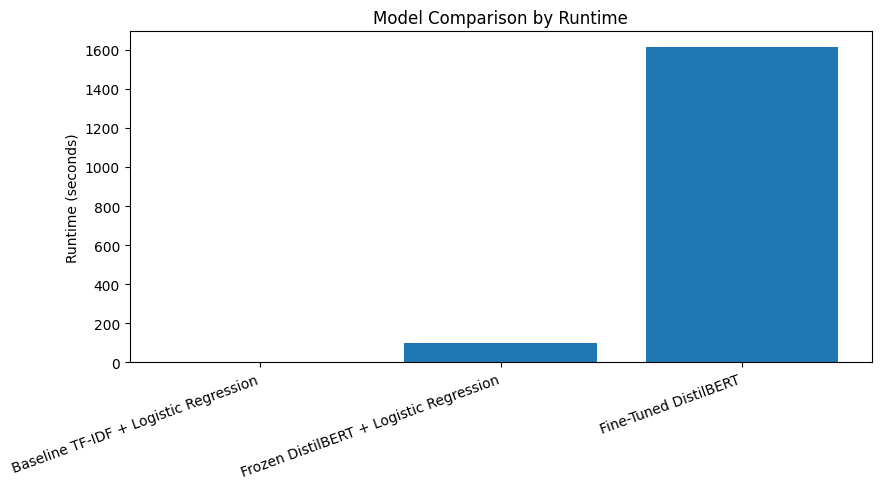

In [15]:
# =========================
# [9] COMPARE RESULTS
# =========================

results_table = pd.DataFrame([
    {
        "Model": "Baseline TF-IDF + Logistic Regression",
        "Accuracy": baseline_metrics["accuracy"],
        "Precision": baseline_metrics["precision"],
        "Recall": baseline_metrics["recall"],
        "F1": baseline_metrics["f1"],
        "Runtime_sec": baseline_runtime
    },
    {
        "Model": "Frozen DistilBERT + Logistic Regression",
        "Accuracy": frozen_metrics["accuracy"],
        "Precision": frozen_metrics["precision"],
        "Recall": frozen_metrics["recall"],
        "F1": frozen_metrics["f1"],
        "Runtime_sec": feature_extraction_runtime + frozen_train_runtime
    },
    {
        "Model": "Fine-Tuned DistilBERT",
        "Accuracy": finetune_metrics["accuracy"],
        "Precision": finetune_metrics["precision"],
        "Recall": finetune_metrics["recall"],
        "F1": finetune_metrics["f1"],
        "Runtime_sec": finetune_runtime
    }
])

results_table

# Bar plot comparison for F1-score
plt.figure(figsize=(9, 5))
plt.bar(results_table["Model"], results_table["F1"])
plt.ylabel("F1 Score")
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Bar plot comparison for runtime
plt.figure(figsize=(9, 5))
plt.bar(results_table["Model"], results_table["Runtime_sec"])
plt.ylabel("Runtime (seconds)")
plt.title("Model Comparison by Runtime")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### For part 9: COMPARE RESULTS

Combined the results of all three models into one comparison table and compared models using the same evaluation criteria.

Visualized:

    final F1-score
    total runtime

This enables direct comparison of:

    - predictive quality
    - computational cost
    - benefit of transfer learning
    - benefit of fine-tuning

In [16]:
# Extra: save numeric results for later reference / report tables

results_table.to_csv("lab2_model_comparison_results.csv", index=False)
print("Results saved to lab2_model_comparison_results.csv")

Results saved to lab2_model_comparison_results.csv


### Dataset overview

The selected dataset is a binary SMS classification dataset with two classes: ham and spam. This is a many-to-one sequence classification task because each full message is mapped to a single label. The problem is a good fit for transfer learning because SMS spam detection depends on both local lexical cues such as promotional words, links, and urgency phrases, and broader contextual patterns such as intent and tone. It is also a practical trust-and-safety problem, since accurate spam filtering reduces exposure to fraud, phishing, nuisance messaging, and social engineering. Because the input consists only of text, the task is unimodal and well aligned with pretrained language models.

### Foundational model

DistilBERT was selected as the foundational model. DistilBERT is a compressed transformer encoder derived from BERT through knowledge distillation, so it retains much of BERT's language understanding while using fewer parameters and less computation. That tradeoff is useful in this lab because it makes full fine-tuning more feasible while still providing strong pretrained semantic representations. The source and target tasks are both natural language understanding problems, so the transfer is in-domain. This matters because the model already starts with useful representations of syntax, word meaning, phrase composition, and contextual relationships before seeing any SMS-specific supervision.

### Split and loss

An 80/20 train-test split was used with stratification. Stratification was important because the dataset is imbalanced, with ham messages appearing more frequently than spam. Preserving that ratio in both splits makes the evaluation more realistic and avoids accidentally making one split easier or harder than the other. For the fine-tuned transformer, cross-entropy loss is appropriate because the task is single-label binary classification. It directly optimizes the model to assign high probability to the correct class, and it works naturally with the logits produced by the sequence-classification head.

### Baseline model

The baseline used TF-IDF features with logistic regression. This is a strong traditional approach for short-text classification because many spam messages contain highly informative keywords and short phrases that TF-IDF can capture well. The baseline performed surprisingly strongly: accuracy = 0.9749, precision = 0.8854, recall = 0.9329, and F1 = 0.9085, with runtime of only about 0.24 seconds. These results show that the dataset contains substantial lexical signal and that a simple linear classifier already separates many spam and ham messages effectively. However, the lower precision relative to the transformer models suggests that the baseline still produces more false positives, which is costly in a spam-filtering setting because legitimate messages may be incorrectly flagged.

### Transfer Learning

In the frozen-transfer stage, DistilBERT was used only as a pretrained feature extractor, and a logistic regression classifier was trained on top of the fixed embeddings. This model improved on the baseline across every major quality metric: accuracy = 0.9874, precision = 0.9470, recall = 0.9597, and F1 = 0.9533. The jump in F1 from 0.9085 to 0.9533 shows that pretrained contextual representations provide clear value even when the backbone is not updated. In particular, the large precision gain indicates fewer false spam predictions than the TF-IDF baseline. The tradeoff is runtime: the frozen approach took about 101.38 seconds because embedding extraction is much more expensive than fitting a sparse linear model directly on TF-IDF features.

### Fine-tuning

In the fine-tuning stage, the DistilBERT weights were updated end to end for the SMS classification task. This produced the best overall results: accuracy = 0.9910, precision = 0.9728, recall = 0.9597, and F1 = 0.9662. Compared with the frozen-transfer model, fine-tuning gave a smaller but still meaningful F1 improvement, from 0.9533 to 0.9662. Interestingly, recall stayed the same while precision improved further, which suggests that the main benefit of fine-tuning in this experiment was reducing false positives rather than finding additional spam messages. The main cost was computation: fine-tuning took about 1613.33 seconds, or roughly 26.9 minutes, which is far slower than both the baseline and the frozen-transfer approach.

### Results/discussion

The experiment shows a clear performance hierarchy. The baseline model was fastest by a very large margin and still achieved strong quality, confirming that TF-IDF plus logistic regression remains a solid benchmark for short text classification. The frozen DistilBERT model demonstrated that transfer learning adds substantial value even without end-to-end adaptation, raising F1 by about 0.045 over the baseline. The fine-tuned DistilBERT model delivered the best overall performance, with the highest accuracy, precision, and F1, and an F1 gain of about 0.058 over the baseline.

At the same time, the runtime comparison highlights an important engineering tradeoff. The baseline is extremely efficient and may be preferable when compute or latency matters most. The frozen-transfer model offers a middle ground: much better predictive quality than the baseline, but far cheaper than full fine-tuning. The fine-tuned model is the best choice when maximizing classification quality is the priority and the extra training cost is acceptable. The higher training cost for Full Fine Tuning should be noted that it took ~16x the amount of training time for a 0.01 increase in F1 Score. Overall, the results support the practical value of transfer learning for SMS spam detection, and they show that full fine-tuning yields the strongest classifier in this specific experiment at the cost of computation and runtime.

### Limitations

- The dataset is relatively small for transformer fine-tuning, so the measured gains may be sensitive to the specific split.
- The task is class-imbalanced, which means accuracy alone can overstate performance; F1, precision, and recall are more informative.
- SMS messages are short and often noisy, with abbreviations, misspellings, and ambiguous intent, which can still confuse all three models.
- Only one random train-test split appears to have been used, so the results do not capture variability across repeated runs or cross-validation folds.
- Hyperparameters were not extensively tuned, so the baseline, frozen-transfer, and fine-tuned models may all have room for further improvement.
- Runtime comparisons depend on hardware availability, especially whether GPU acceleration was used during transformer stages.
- The evaluation focuses on aggregate metrics and does not deeply analyze the specific error cases or message types each model gets wrong.